# Simulation Spatio-Temporelle — État Hydrique ApexVigne

Génère des observations synthétiques de stress hydrique compatibles avec `data/data_apex.csv`.

## Architecture
**Vérité terrain (ground truth)**
- Statique : gaussiennes multivariées sur (altitude_norm, RU_continue_norm)
- Temporelle : modulation hebdomadaire par CWB + bruit AR(1) corrélé spatialement

**Processus d'observation (biaisé)**
- `N_PARCELLES` positions fixes dans `study_zone_viti` (biais spatial)
- Positions stables dans le temps (jitter GPS ±50 m)
- **Biais temporel** : intensité d'observation variable par semaine (profil unimodal)
- Comptages `(apex0, apex1, apex2)` via Dirichlet-Multinomial depuis iC-APEX réel

**Outputs** → `simulation_results/`
- `ground_truth/static_ground_truth.tif`
- `ground_truth/hydric_state_YYYY-MM-DD.tif` (une par semaine)
- `observations/simulated_apex_data.csv`
- `figures/*.png`

## 0. IMPORTS & CONFIGURATION

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D
import os
import sys
from tqdm import tqdm
from shapely.geometry import Point

# Simulation utilities (simulation_utils/hydric_simulation.py)
sys.path.insert(0, os.getcwd())
from simulation_utils.hydric_simulation import (
    load_and_align_rasters,
    build_study_mask,
    build_static_ground_truth,
    build_temporal_ground_truth,
    generate_virtual_parcelles,
    temporal_observation_weights,
    sample_apex_counts,
    sample_n_total,
    get_value_at_coord,
    build_apex_dataframe,
    save_ground_truth_raster,
)

np.random.seed(42)
print('✅ Imports OK')

✅ Imports OK


In [3]:
# ── Chemins ──────────────────────────────────────────────────────────────────
PATHS = {
    'alt'        : 'data/cov/rasters/alt/altitude_study_zone.tif',
    'ru'         : 'data/cov/rasters/ru/ru_raster.tif',
    'cwb_dir'    : 'data/cov/rasters/cwb/',
    'study_zone' : 'data/study_zone_viti.gpkg',
    'data_apex'  : 'data/data_apex.csv',
    'output'     : 'simulation_results',
}

# ── Paramètres de simulation ─────────────────────────────────────────────────
SIM = {
    # Ground truth
    'smooth_sigma_static' : 2.5,   # lissage spatial (pixels)
    # Processus temporel AR(1)
    'ar1_rho'             : 0.80,  # autocorrélation temporelle
    'cwb_weight'          : 0.35,  # poids du CWB hebdo vs composante statique
    'noise_sigma'         : 0.04,  # amplitude du bruit AR(1)
    'spatial_smooth_noise': 1.5,   # lissage spatial du bruit (pixels)
    # Parcelles
    'n_parcelles'         : 300,
    'gps_jitter_m'        : 50,    # écart-type du jitter GPS en mètres
    # Observations
    'n_obs_total'         : 1200,  # nombre total d'observations sur toute la saison
    'temporal_pattern'    : 'unimodal',  # 'unimodal','bimodal','decreasing','random','uniform'
    # Comptages apex
    'mean_n_apices'       : 50,    # moyenne du total (apex0+apex1+apex2)
    'n_apex_dispersion'   : 0.4,   # dispersion NegBin
    'dirichlet_conc'      : 6.0,   # concentration Dirichlet (> = moins de bruit observateur)
    'seed'                : 42,
}

# ── Dossiers de sortie ───────────────────────────────────────────────────────
for sub in ['', 'ground_truth', 'observations', 'figures']:
    os.makedirs(os.path.join(PATHS['output'], sub), exist_ok=True)

print('✅ Configuration prête')
print(f"   Output : {PATHS['output']}/")
print(f"   Parcelles    : {SIM['n_parcelles']}")
print(f"   Observations : {SIM['n_obs_total']}")
print(f"   AR(1) rho    : {SIM['ar1_rho']}  |  CWB weight : {SIM['cwb_weight']}")

✅ Configuration prête
   Output : simulation_results/
   Parcelles    : 300
   Observations : 1200
   AR(1) rho    : 0.8  |  CWB weight : 0.35


## 1. CHARGEMENT DES COVARIABLES

In [4]:
study_zone = gpd.read_file(PATHS['study_zone'])
print(f'📐 Zone d\'étude  : {len(study_zone)} polygones — CRS : {study_zone.crs}')

print('\n🌡️  Chargement et alignement des rasters...')
alt_arr, ru_arr, cwb_aligned, ref_transform, ref_crs, ref_shape = load_and_align_rasters(
    PATHS['alt'], PATHS['ru'], PATHS['cwb_dir'], study_zone
)

study_mask  = build_study_mask(alt_arr)
sorted_dates = sorted(cwb_aligned.keys())
n_weeks      = len(sorted_dates)

print(f'\n✅ Rasters chargés !')
print(f'   Grille de référence (altitude) : {ref_shape[1]} × {ref_shape[0]} pixels')
print(f'   Pixels dans la zone d\'étude   : {study_mask.sum():,}')
print(f'   Semaines CWB disponibles       : {n_weeks}')
print(f'   Période : {sorted_dates[0]}  →  {sorted_dates[-1]}')
print(f'\n   Altitude  : min={np.nanmin(alt_arr):.0f} m, max={np.nanmax(alt_arr):.0f} m')

ru_classes, ru_counts = np.unique(ru_arr[study_mask & np.isfinite(ru_arr)].astype(int),
                                   return_counts=True)
print('   Classes RU (dans zone) :', dict(zip(ru_classes.tolist(), ru_counts.tolist())))

📐 Zone d'étude  : 1 polygones — CRS : EPSG:2154

🌡️  Chargement et alignement des rasters...

✅ Rasters chargés !
   Grille de référence (altitude) : 424 × 337 pixels
   Pixels dans la zone d'étude   : 35,039
   Semaines CWB disponibles       : 13
   Période : 2025-06-08  →  2025-08-31

   Altitude  : min=-11 m, max=2579 m
   Classes RU (dans zone) : {0: 421, 1: 14058, 2: 9315, 3: 5862, 4: 5013, 5: 18, 9: 352}


## 2. VÉRITÉ TERRAIN — COMPOSANTE STATIQUE (Gaussiennes Multivariées)

In [5]:
static_map, alt_norm, ru_norm = build_static_ground_truth(
    alt_arr, ru_arr, study_mask,
    smooth_sigma=SIM['smooth_sigma_static']
)

valid_vals = static_map[study_mask]
print('✅ Carte statique construite !')
print(f'   iC-APEX statique — min : {np.nanmin(valid_vals):.3f}')
print(f'                    — moy : {np.nanmean(valid_vals):.3f}')
print(f'                    — max : {np.nanmax(valid_vals):.3f}')
print(f'   % cellules avec iC-APEX < 0.5 (stress) : {(valid_vals < 0.5).mean()*100:.1f}%')

✅ Carte statique construite !
   iC-APEX statique — min : 0.000
                    — moy : 0.339
                    — max : 1.000
   % cellules avec iC-APEX < 0.5 (stress) : 73.8%


## 3. VÉRITÉ TERRAIN — COMPOSANTE TEMPORELLE (AR(1) + CWB)

In [6]:
temporal_maps, sorted_dates = build_temporal_ground_truth(
    static_map, cwb_aligned, study_mask,
    ar1_rho       = SIM['ar1_rho'],
    cwb_weight    = SIM['cwb_weight'],
    noise_sigma   = SIM['noise_sigma'],
    spatial_smooth= SIM['spatial_smooth_noise'],
    seed          = SIM['seed'],
)

print(f'✅ {len(temporal_maps)} cartes temporelles construites')
print(f'   AR(1) rho = {SIM["ar1_rho"]}  |  CWB weight = {SIM["cwb_weight"]}')
print('\n   iC-APEX moyen par semaine :')
for d in sorted_dates:
    m = float(np.nanmean(temporal_maps[d][study_mask]))
    bar = '█' * int(m * 30)
    print(f'   {d}  {m:.3f}  {bar}')

✅ 13 cartes temporelles construites
   AR(1) rho = 0.8  |  CWB weight = 0.35

   iC-APEX moyen par semaine :
   2025-06-08  0.459  █████████████
   2025-06-15  0.437  █████████████
   2025-06-22  0.416  ████████████
   2025-06-29  0.397  ███████████
   2025-07-06  0.382  ███████████
   2025-07-13  0.373  ███████████
   2025-07-20  0.367  ██████████
   2025-07-27  0.341  ██████████
   2025-08-03  0.326  █████████
   2025-08-10  0.313  █████████
   2025-08-17  0.302  █████████
   2025-08-24  0.295  ████████
   2025-08-31  0.312  █████████


## 4. VISUALISATION DE LA VÉRITÉ TERRAIN

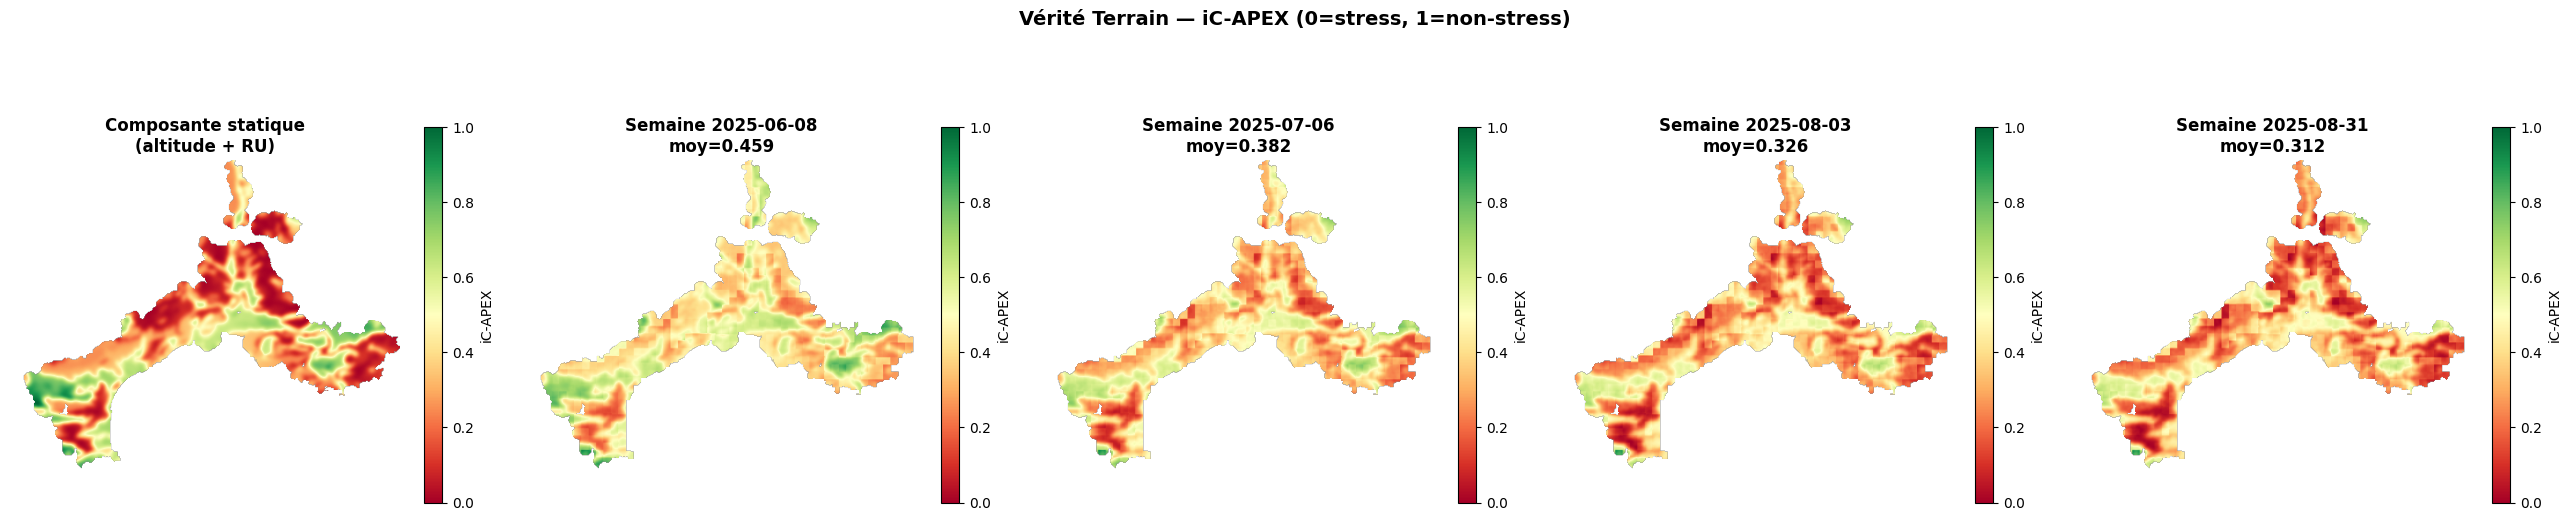

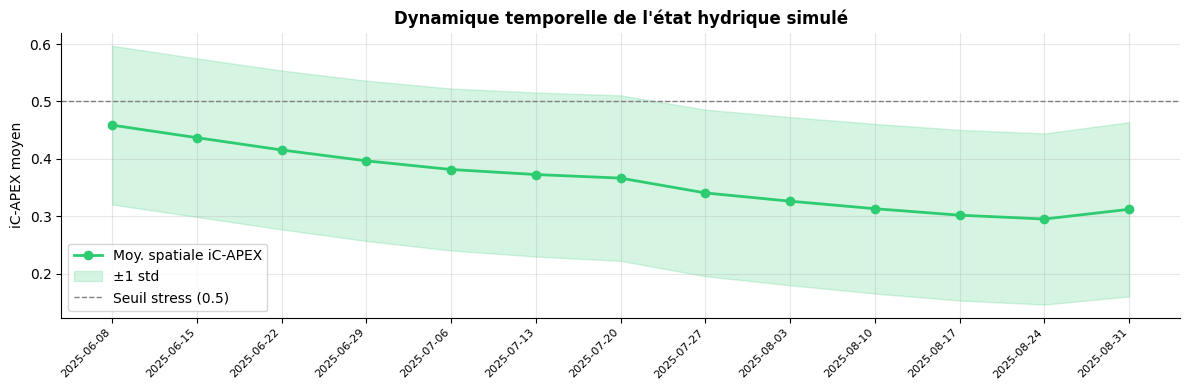

In [7]:
study_zone_wgs = study_zone.to_crs('EPSG:4326')

# Sélection de 4 semaines représentatives
idx_sel = [0, n_weeks // 3, 2 * n_weeks // 3, n_weeks - 1]
sel_dates = [sorted_dates[i] for i in idx_sel]

fig, axes = plt.subplots(1, 5, figsize=(26, 6))

# ── Carte statique ────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_title('Composante statique\n(altitude + RU)', fontweight='bold')
im = ax.imshow(static_map, cmap='RdYlGn', vmin=0, vmax=1, origin='upper')
plt.colorbar(im, ax=ax, shrink=0.7, label='iC-APEX')
ax.axis('off')

# ── 4 semaines ───────────────────────────────────────────────────────────────
for ax, date_str in zip(axes[1:], sel_dates):
    h = temporal_maps[date_str]
    im = ax.imshow(h, cmap='RdYlGn', vmin=0, vmax=1, origin='upper')
    m  = float(np.nanmean(h[study_mask]))
    ax.set_title(f'Semaine {date_str}\nmoy={m:.3f}', fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.7, label='iC-APEX')
    ax.axis('off')

plt.suptitle('Vérité Terrain — iC-APEX (0=stress, 1=non-stress)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PATHS['output']}/figures/ground_truth_maps.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Série temporelle : moyenne spatiale ──────────────────────────────────────
means = [float(np.nanmean(temporal_maps[d][study_mask])) for d in sorted_dates]
stds  = [float(np.nanstd( temporal_maps[d][study_mask])) for d in sorted_dates]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(n_weeks), means, 'o-', color='#2ecc71', lw=2, label='Moy. spatiale iC-APEX')
ax.fill_between(range(n_weeks),
                [m - s for m, s in zip(means, stds)],
                [m + s for m, s in zip(means, stds)],
                alpha=0.2, color='#2ecc71', label='±1 std')
ax.axhline(0.5, color='grey', linestyle='--', lw=1, label='Seuil stress (0.5)')
ax.set_xticks(range(n_weeks))
ax.set_xticklabels(sorted_dates, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('iC-APEX moyen')
ax.set_title('Dynamique temporelle de l\'état hydrique simulé', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PATHS['output']}/figures/temporal_dynamics.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. PARCELLES VIRTUELLES (Positions Fixes)

✅ 300 parcelles virtuelles générées (EPSG:2154)
   iC-APEX statique aux parcelles — moy : 0.339  std : 0.244


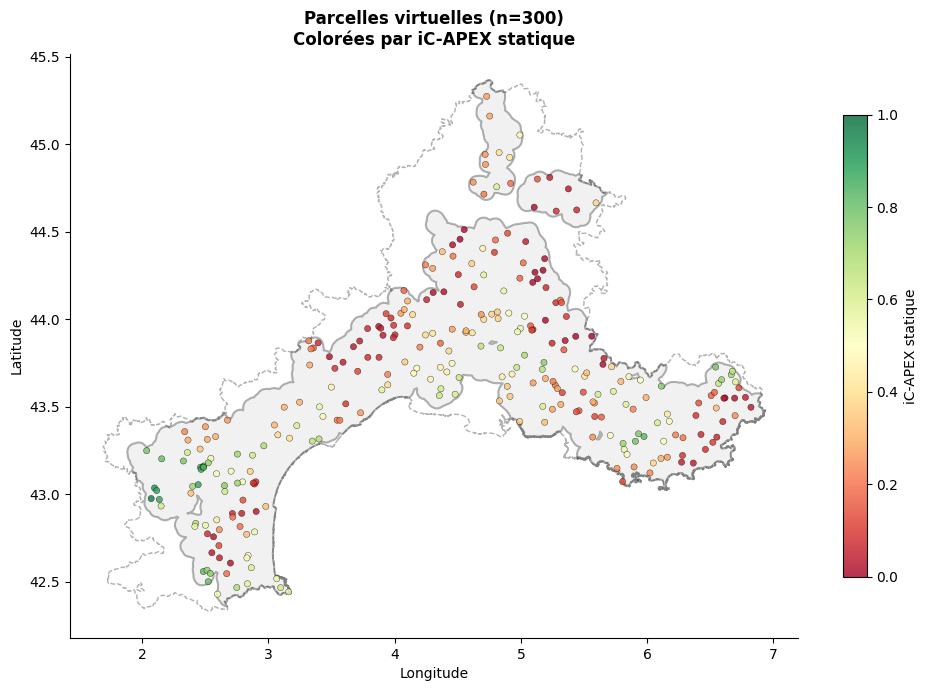

In [8]:
parcelles = generate_virtual_parcelles(
    study_zone, n_parcelles=SIM['n_parcelles'], seed=SIM['seed']
)
# Version WGS84 pour visualisation
parcelles_wgs = parcelles.to_crs('EPSG:4326')

print(f'✅ {len(parcelles)} parcelles virtuelles générées (EPSG:2154)')

# Extraire la valeur statique à chaque parcelle
ic_static_parcelles = np.array([
    get_value_at_coord(row.geometry.x, row.geometry.y, static_map, ref_transform)
    for _, row in parcelles.iterrows()
])
valid_ic = ic_static_parcelles[np.isfinite(ic_static_parcelles)]
print(f'   iC-APEX statique aux parcelles — moy : {valid_ic.mean():.3f}  std : {valid_ic.std():.3f}')

# ── Visualisation ─────────────────────────────────────────────────────────────
study_zone_bg = gpd.read_file('data/study_zone.gpkg').to_crs('EPSG:4326')

fig, ax = plt.subplots(figsize=(10, 8))
study_zone_bg.plot(ax=ax, facecolor='none', edgecolor='grey', linewidth=1,
                    linestyle='--', alpha=0.6)
study_zone_wgs.plot(ax=ax, facecolor='lightgrey', edgecolor='black',
                     linewidth=1.5, alpha=0.3)
sc = ax.scatter(
    parcelles_wgs.geometry.x,
    parcelles_wgs.geometry.y,
    c=ic_static_parcelles,
    cmap='RdYlGn', vmin=0, vmax=1,
    s=20, alpha=0.8, edgecolors='k', linewidths=0.3
)
plt.colorbar(sc, ax=ax, shrink=0.6, label='iC-APEX statique')
ax.set_title(f'Parcelles virtuelles (n={len(parcelles)})\nColorées par iC-APEX statique',
              fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PATHS['output']}/figures/parcelles_virtuelles.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. INTENSITÉ D'OBSERVATION TEMPORELLE (Biais Temporel)

✅ Intensité temporelle (unimodal) :
   Total observations planifiées : 1,200

   2025-06-08     2  ██
   2025-06-15     8  ████████
   2025-06-22    23  ███████████████████████
   2025-06-29    55  ███████████████████████████████████████████████████████
   2025-07-06   108  ████████████████████████████████████████████████████████████████████████████████████████████████████████████
   2025-07-13   169  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   2025-07-20   214  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   2025-07-27   219  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

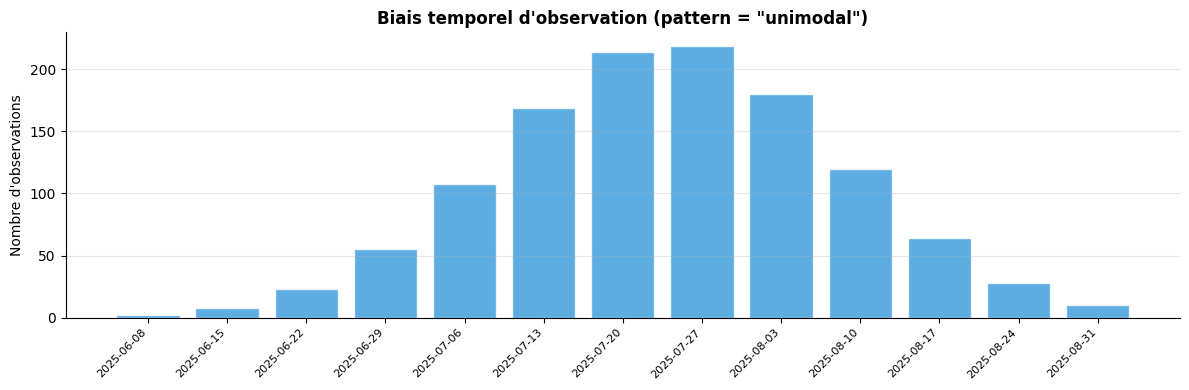

In [9]:
obs_weights = temporal_observation_weights(
    n_weeks, pattern=SIM['temporal_pattern'], seed=SIM['seed']
)
n_obs_per_week = np.round(obs_weights * SIM['n_obs_total']).astype(int)
# Ajustement du total pour qu'il soit exact
diff = SIM['n_obs_total'] - n_obs_per_week.sum()
n_obs_per_week[np.argmax(n_obs_per_week)] += diff

print(f'✅ Intensité temporelle ({SIM["temporal_pattern"]}) :')
print(f'   Total observations planifiées : {n_obs_per_week.sum():,}')
print()
for d, n in zip(sorted_dates, n_obs_per_week):
    bar = '█' * n
    print(f'   {d}  {n:4d}  {bar}')

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(n_weeks), n_obs_per_week, color='#3498db', alpha=0.8, edgecolor='white')
ax.set_xticks(range(n_weeks))
ax.set_xticklabels(sorted_dates, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Nombre d\'observations')
ax.set_title(f'Biais temporel d\'observation (pattern = "{SIM["temporal_pattern"]}")',
              fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PATHS['output']}/figures/temporal_bias.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. SIMULATION DES OBSERVATIONS

In [10]:
rng = np.random.default_rng(SIM['seed'])

# Pré-calculer les coordonnées Lambert des parcelles
parcel_x = np.array([g.x for g in parcelles.geometry])
parcel_y = np.array([g.y for g in parcelles.geometry])
parcel_ids     = parcelles['id_parcelle'].values
parcel_obs_ids = parcelles['id_observateur'].values

observations_raw = []   # stocke {x_lam, y_lam, date, apex0/1/2, ...}
skipped = 0

print('🚀 Simulation des observations...')
for t, (date_str, n_obs) in enumerate(
        tqdm(zip(sorted_dates, n_obs_per_week), total=n_weeks, desc='Semaines')):
    if n_obs == 0:
        continue

    hydric_map = temporal_maps[date_str]

    # Tirer les indices de parcelles pour cette semaine (avec remise)
    idx_selected = rng.choice(len(parcelles), size=n_obs, replace=True)

    for idx in idx_selected:
        x0, y0 = parcel_x[idx], parcel_y[idx]

        # Jitter GPS (±SIM['gps_jitter_m'] m en Lambert)
        x_obs = x0 + rng.normal(0, SIM['gps_jitter_m'])
        y_obs = y0 + rng.normal(0, SIM['gps_jitter_m'])

        # iC-APEX vrai à cette position
        ic_true = get_value_at_coord(x_obs, y_obs, hydric_map, ref_transform)
        if np.isnan(ic_true):   # jitter hors zone → repli sur position centrale
            ic_true = get_value_at_coord(x0, y0, hydric_map, ref_transform)
        if np.isnan(ic_true):
            skipped += 1
            continue

        # Comptages apex via Dirichlet-Multinomial
        n_total = sample_n_total(SIM['mean_n_apices'], SIM['n_apex_dispersion'], rng)
        a0, a1, a2 = sample_apex_counts(ic_true, n_total, SIM['dirichlet_conc'], rng)

        observations_raw.append({
            'date_session'  : date_str,
            'x_lambert'     : x_obs,
            'y_lambert'     : y_obs,
            'apex0'         : a0,
            'apex1'         : a1,
            'apex2'         : a2,
            'id_parcelle'   : parcel_ids[idx],
            'id_observateur': parcel_obs_ids[idx],
            'ic_apex_true'  : ic_true,
        })

print(f'\n✅ {len(observations_raw):,} observations générées  ({skipped} ignorées hors zone)')

# ── Reprojection Lambert → WGS84 (en bloc) ───────────────────────────────────
obs_tmp = pd.DataFrame(observations_raw)
gdf_lam = gpd.GeoDataFrame(
    obs_tmp,
    geometry=gpd.points_from_xy(obs_tmp['x_lambert'], obs_tmp['y_lambert']),
    crs='EPSG:2154'
)
gdf_wgs84 = gdf_lam.to_crs('EPSG:4326')
obs_tmp['longitude_wgs84'] = gdf_wgs84.geometry.x
obs_tmp['latitude_wgs84']  = gdf_wgs84.geometry.y

# Recalculer ic_apex_obs
obs_tmp['ic_apex_obs'] = (
    (obs_tmp['apex0'] + 0.5 * obs_tmp['apex1']) /
    (obs_tmp['apex0'] + obs_tmp['apex1'] + obs_tmp['apex2']).clip(lower=1)
)
print(f'   iC-APEX observé — moy : {obs_tmp["ic_apex_obs"].mean():.3f}  '
      f'std : {obs_tmp["ic_apex_obs"].std():.3f}')

🚀 Simulation des observations...


Semaines: 100%|██████████| 13/13 [00:00<00:00, 230.65it/s]


✅ 1,189 observations générées  (11 ignorées hors zone)
   iC-APEX observé — moy : 0.360  std : 0.200


## 8. CONSTRUCTION DU DATAFRAME & EXPORT

In [11]:
# Construire la liste de dicts pour build_apex_dataframe
observations_list = obs_tmp.to_dict(orient='records')
df_simulated = build_apex_dataframe(observations_list)

# Export CSV
csv_path = f"{PATHS['output']}/observations/simulated_apex_data.csv"
df_simulated.to_csv(csv_path, index=False)

print(f'✅ DataFrame exporté : {csv_path}')
print(f'   Shape   : {df_simulated.shape}')
print(f'   Colonnes: {df_simulated.columns.tolist()}')
print()
print(df_simulated[['date_session','apex0','apex1','apex2',
                     'longitude','latitude','ic_apex_true','ic_apex_obs']].head(5).to_string())

✅ DataFrame exporté : simulation_results/observations/simulated_apex_data.csv
   Shape   : (1189, 22)
   Colonnes: ['id_session', 'date_creation', 'date_maj', 'date_session', 'apex0', 'apex1', 'apex2', 'id_observateur', 'id_parcelle', 'id_stade', 'commentaire', 'device_hardware', 'device_software', 'longitude', 'latitude', 'location', 'en_parcelle', 'est_archivee', 'raison_archive', 'app_version', 'ic_apex_true', 'ic_apex_obs']

  date_session  apex0  apex1  apex2  longitude   latitude  ic_apex_true  ic_apex_obs
0   2025-06-08      4     35     21   4.412842  43.699770      0.560036       0.3583
1   2025-06-08      1     20     38   5.560428  43.903979      0.231656       0.1864
2   2025-06-15      0     22     38   5.888660  43.486441      0.273264       0.1833
3   2025-06-15     16     41      2   6.590454  43.655299      0.699197       0.6186
4   2025-06-15      9     15     28   4.706373  43.999857      0.436621       0.3173


## 9. EXPORT DES RASTERS VÉRITÉ TERRAIN

In [12]:
# Carte statique
static_path = f"{PATHS['output']}/ground_truth/static_ground_truth.tif"
save_ground_truth_raster(static_map, ref_transform, ref_crs, static_path)
print(f'💾 {static_path}')

# Cartes hebdomadaires
print('💾 Cartes temporelles...')
for date_str in tqdm(sorted_dates, desc='Export rasters'):
    out_path = f"{PATHS['output']}/ground_truth/hydric_state_{date_str}.tif"
    save_ground_truth_raster(temporal_maps[date_str], ref_transform, ref_crs, out_path)

print(f'\n✅ {1 + n_weeks} rasters exportés dans {PATHS["output"]}/ground_truth/')

💾 simulation_results/ground_truth/static_ground_truth.tif
💾 Cartes temporelles...


Export rasters: 100%|██████████| 13/13 [00:00<00:00, 317.70it/s]


✅ 14 rasters exportés dans simulation_results/ground_truth/


## 10. VALIDATION — Comparaison Simulé vs Données Réelles

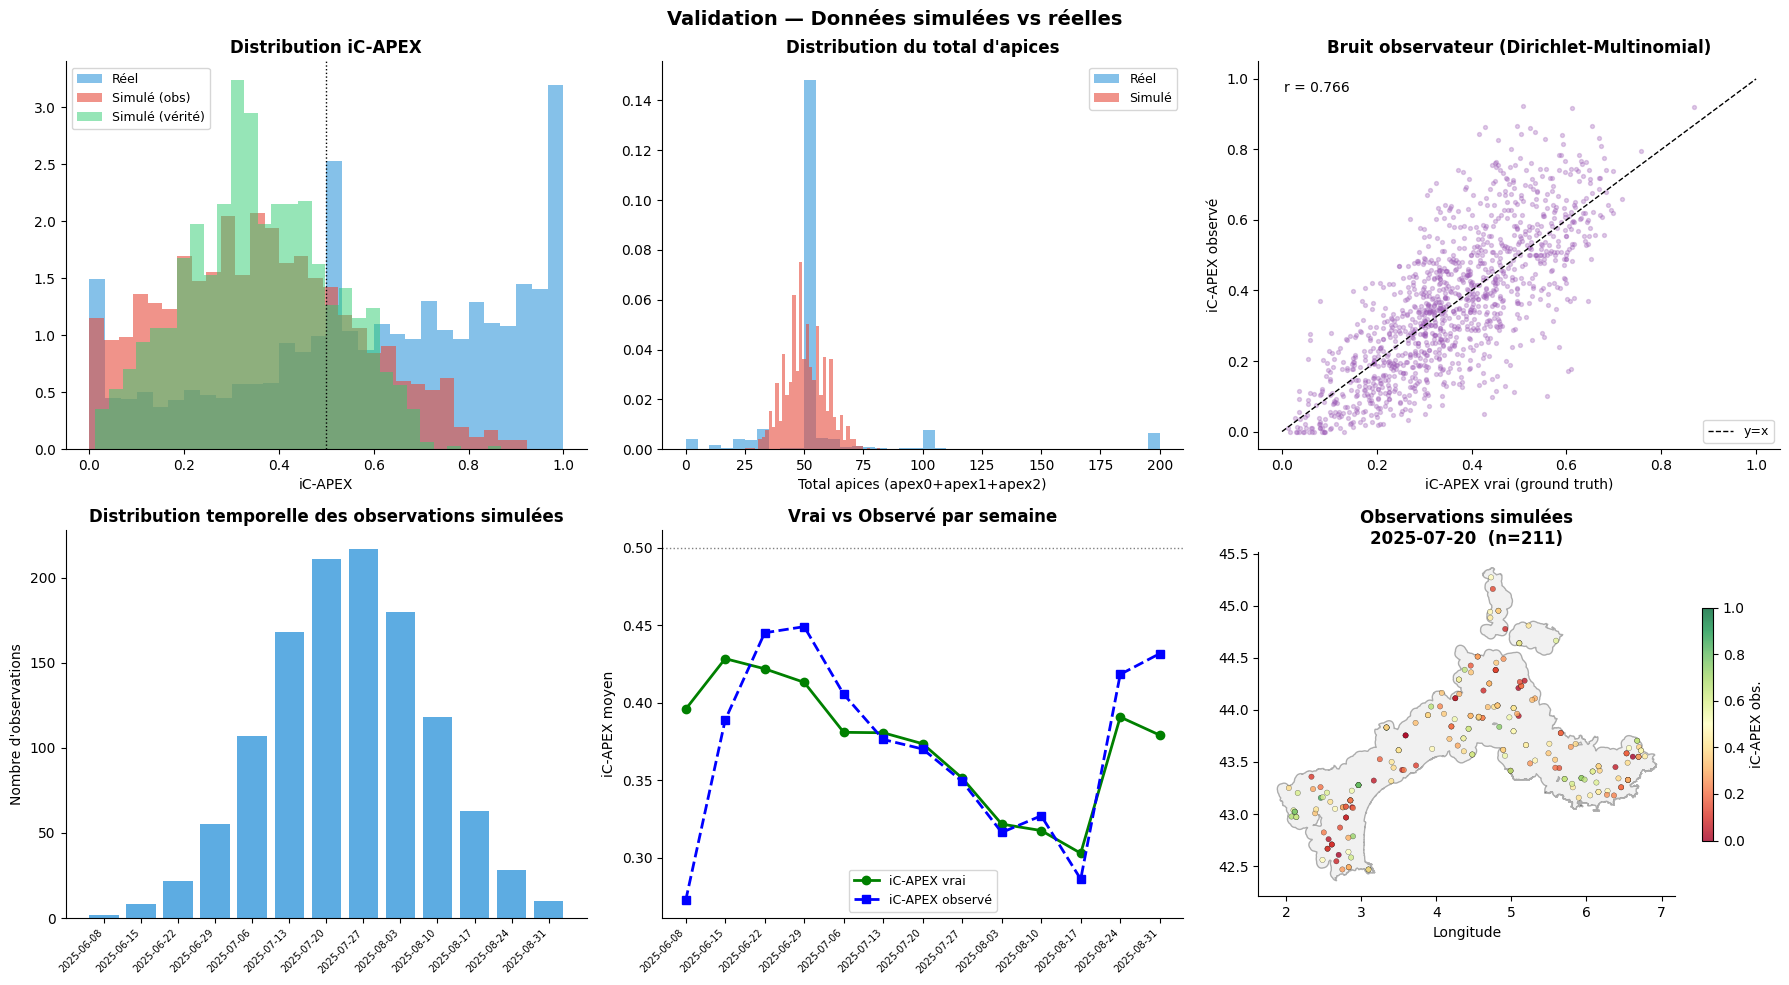


📊 Résumé comparatif
   iC-APEX réel    — moy : 0.602  std : 0.291
   iC-APEX simulé  — moy : 0.360  std : 0.200
   % stress réel   (iC<0.5) : 32.1%
   % stress simulé (iC<0.5) : 74.3%
   Total obs simulées        : 1,189


In [13]:
# Chargement des données réelles pour comparaison
df_real = pd.read_csv(PATHS['data_apex'], encoding='latin1', low_memory=False)
df_real['date_session'] = pd.to_datetime(df_real['date_session'], errors='coerce')
df_real = df_real.dropna(subset=['apex0','apex1','apex2'])
df_real['apex0'] = pd.to_numeric(df_real['apex0'], errors='coerce')
df_real['apex1'] = pd.to_numeric(df_real['apex1'], errors='coerce')
df_real['apex2'] = pd.to_numeric(df_real['apex2'], errors='coerce')
df_real = df_real.dropna(subset=['apex0','apex1','apex2'])
df_real['ic_apex'] = (
    (df_real['apex0'] + 0.5 * df_real['apex1']) /
    (df_real['apex0'] + df_real['apex1'] + df_real['apex2']).clip(lower=1)
)
df_real['total_apex'] = df_real['apex0'] + df_real['apex1'] + df_real['apex2']
df_simulated['total_apex'] = df_simulated['apex0'] + df_simulated['apex1'] + df_simulated['apex2']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── A. Distribution iC-APEX ───────────────────────────────────────────────────
ax = axes[0, 0]
ax.hist(df_real['ic_apex'].dropna(), bins=30, color='#3498db', alpha=0.6,
        label='Réel', density=True)
ax.hist(df_simulated['ic_apex_obs'], bins=30, color='#e74c3c', alpha=0.6,
        label='Simulé (obs)', density=True)
ax.hist(df_simulated['ic_apex_true'], bins=30, color='#2ecc71', alpha=0.5,
        label='Simulé (vérité)', density=True, linestyle='--')
ax.axvline(0.5, color='k', linestyle=':', lw=1)
ax.set_xlabel('iC-APEX')
ax.set_title('Distribution iC-APEX', fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

# ── B. Total apices par observation ──────────────────────────────────────────
ax = axes[0, 1]
ax.hist(df_real['total_apex'].clip(0, 200), bins=40, color='#3498db', alpha=0.6,
        label='Réel', density=True)
ax.hist(df_simulated['total_apex'].clip(0, 200), bins=40, color='#e74c3c', alpha=0.6,
        label='Simulé', density=True)
ax.set_xlabel('Total apices (apex0+apex1+apex2)')
ax.set_title('Distribution du total d\'apices', fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

# ── C. Vérité vs Observé (biais observateur) ─────────────────────────────────
ax = axes[0, 2]
ax.scatter(df_simulated['ic_apex_true'], df_simulated['ic_apex_obs'],
            alpha=0.3, s=8, color='#9b59b6')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='y=x')
ax.set_xlabel('iC-APEX vrai (ground truth)')
ax.set_ylabel('iC-APEX observé')
ax.set_title('Bruit observateur (Dirichlet-Multinomial)', fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

corr = np.corrcoef(df_simulated['ic_apex_true'], df_simulated['ic_apex_obs'])[0, 1]
ax.text(0.05, 0.92, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=10)

# ── D. Observations par semaine (simulées) ────────────────────────────────────
ax = axes[1, 0]
obs_by_week = df_simulated.groupby('date_session').size()
ax.bar(range(len(obs_by_week)), obs_by_week.values, color='#3498db', alpha=0.8)
ax.set_xticks(range(len(obs_by_week)))
ax.set_xticklabels(obs_by_week.index, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Nombre d\'observations')
ax.set_title('Distribution temporelle des observations simulées', fontweight='bold')
ax.spines[['top','right']].set_visible(False)

# ── E. Dynamique temporelle iC-APEX moyen observé vs vrai ────────────────────
ax = axes[1, 1]
ic_obs_by_week  = df_simulated.groupby('date_session')['ic_apex_obs'].mean()
ic_true_by_week = df_simulated.groupby('date_session')['ic_apex_true'].mean()
ax.plot(range(n_weeks), ic_true_by_week.values, 'g-o', lw=2, ms=6, label='iC-APEX vrai')
ax.plot(range(n_weeks), ic_obs_by_week.values,  'b--s', lw=2, ms=6, label='iC-APEX observé')
ax.axhline(0.5, color='grey', linestyle=':', lw=1)
ax.set_xticks(range(n_weeks))
ax.set_xticklabels(sorted_dates, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('iC-APEX moyen')
ax.set_title('Vrai vs Observé par semaine', fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

# ── F. Carte spatiale des observations simulées (1 semaine) ──────────────────
ax = axes[1, 2]
week_plot = sorted_dates[n_weeks // 2]
df_week = df_simulated[df_simulated['date_session'] == week_plot]
study_zone_wgs.plot(ax=ax, facecolor='lightgrey', edgecolor='black', linewidth=1, alpha=0.3)
sc = ax.scatter(
    df_week['longitude'], df_week['latitude'],
    c=df_week['ic_apex_obs'], cmap='RdYlGn', vmin=0, vmax=1,
    s=15, alpha=0.8, edgecolors='k', linewidths=0.2
)
plt.colorbar(sc, ax=ax, shrink=0.6, label='iC-APEX obs.')
ax.set_title(f'Observations simulées\n{week_plot}  (n={len(df_week)})', fontweight='bold')
ax.set_xlabel('Longitude')
ax.spines[['top','right']].set_visible(False)

plt.suptitle('Validation — Données simulées vs réelles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PATHS['output']}/figures/validation.png", dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Résumé comparatif')
print('='*55)
print(f'   iC-APEX réel    — moy : {df_real["ic_apex"].mean():.3f}  '
      f'std : {df_real["ic_apex"].std():.3f}')
print(f'   iC-APEX simulé  — moy : {df_simulated["ic_apex_obs"].mean():.3f}  '
      f'std : {df_simulated["ic_apex_obs"].std():.3f}')
print(f'   % stress réel   (iC<0.5) : {(df_real["ic_apex"]<0.5).mean()*100:.1f}%')
print(f'   % stress simulé (iC<0.5) : {(df_simulated["ic_apex_obs"]<0.5).mean()*100:.1f}%')
print(f'   Total obs simulées        : {len(df_simulated):,}')

## Récapitulatif des fichiers produits

```
simulation_results/
├── ground_truth/
│   ├── static_ground_truth.tif          ← Carte statique (altitude+RU)
│   └── hydric_state_YYYY-MM-DD.tif      ← Une carte par semaine (AR1+CWB)
├── observations/
│   └── simulated_apex_data.csv          ← Format data_apex.csv + ic_apex_true
└── figures/
    ├── ground_truth_maps.png
    ├── temporal_dynamics.png
    ├── parcelles_virtuelles.png
    ├── temporal_bias.png
    └── validation.png
```